# Ex01 — Hour 1: Detect anomaly + extract precursor signals

**Goal:** Given a real production-style metric stream, find anomalies BEFORE the alert fires.

**Scenarios in scope (Hour 1):** S01 (ESB pool exhaust), S02 (DNS NXDOMAIN burst), S03 (Python GIL contention).

**What you'll do:**
1. Load metric timeseries, plot baseline vs incident period
2. Apply 3 detection methods: 3σ, IsolationForest, monotonic-drift detector
3. Compare detection latency (how many minutes BEFORE the alert did each method fire?)
4. Discuss tradeoffs: false-positive rate vs detection earliness


In [1]:
# Auto-detect and install missing required libraries in the current Jupyter kernel
import sys
import subprocess

required_libs = ["pandas", "matplotlib", "networkx", "numpy", "statsmodels", "scikit-learn"]
missing_libs = []

for lib in required_libs:
    try:
        # Handle mapping from import name to pip package name if different
        import_name = "sklearn" if lib == "scikit-learn" else lib
        __import__(import_name)
    except ImportError:
        missing_libs.append(lib)

if missing_libs:
    print(f"Missing libraries: {missing_libs}. Installing...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing_libs)
        print("Successfully installed missing libraries!")
    except Exception as e:
        print(f"Error installing libraries: {e}")
else:
    print("All required libraries are already installed.")


Missing libraries: ['networkx', 'statsmodels', 'scikit-learn']. Installing...
Error installing libraries: Command '['c:\\Users\\MSII\\AppData\\Roaming\\uv\\python\\cpython-3.13.12-windows-x86_64-none\\python.exe', '-m', 'pip', 'install', 'networkx', 'statsmodels', 'scikit-learn']' returned non-zero exit status 1.


In [2]:
import sqlite3, json, importlib.util
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Connect to workshop database
for path in [Path("workshop.db"), Path("../workshop.db")]:
    if path.exists():
        DB = path.resolve()
        break
else:
    DB = (Path.cwd().parent / "workshop.db").resolve()
conn = sqlite3.connect(DB)

# Helper to import modules with kebab-case filenames (workshop convention)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m

print(f"DB: {DB} ({DB.stat().st_size//1024} KB)")
print(f"Tables: {[r[0] for r in conn.execute('SELECT name FROM sqlite_master WHERE type=\"table\"').fetchall()]}")


DB: D:\AWS\AIOPS-study\workshop-student-20260611\workshop.db (2432 KB)
Tables: ['services', 'topology', 'metrics', 'alerts', 'log_patterns', 'sqlite_sequence', 'traces', 'scenarios', 'live_events', 'live_state']


## 1. Browse the data

First, see what metrics are tracked per service for S01.

In [3]:
df = pd.read_sql('''SELECT service, metric, COUNT(*) as n, MIN(value) as min_v, MAX(value) as max_v
                    FROM metrics WHERE scenario = 'S01'
                    GROUP BY service, metric ORDER BY service, metric''', conn)
df


,service,metric,n,min_v,max_v
0,datapower,cpu_cores,105,0.019198,0.020971
1,datapower,error_rate,105,0.000000,0.143951
2,datapower,latency_p50_ms,105,275.038421,307.131920
3,datapower,latency_p99_ms,105,888.429706,2047.200458
4,datapower,mem_mb,105,140.788763,151.170376
5,datapower,rps,105,7.181285,8.048623
6,esb,conn_pool_used,105,28.451288,68.079331
7,esb,cpu_cores,105,0.057414,0.062147
8,esb,error_rate,105,0.000000,0.121361
9,esb,latency_p50_ms,105,281.024425,314.470793


## 2. Plot ESB latency p99 across the entire scenario

The scenario has 4 phases: baseline (60min) → pre (15min) → active (15min) → post (10min) → recovery (5min).
Look for where the curve breaks from baseline.

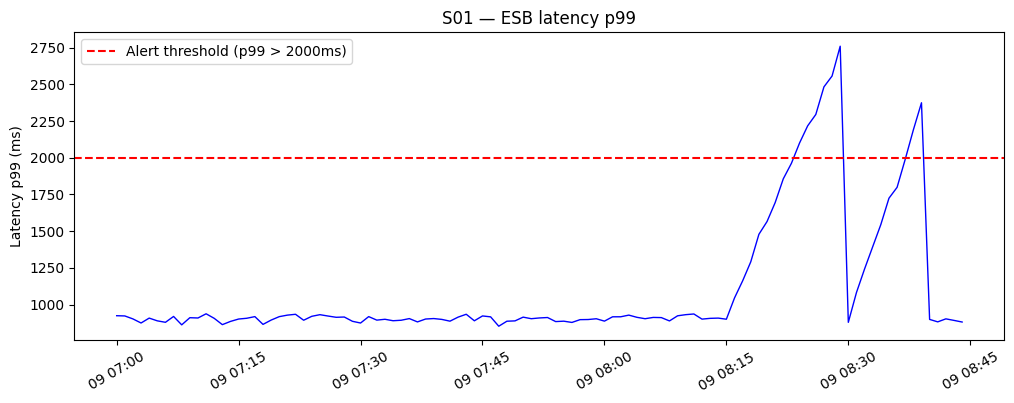

In [4]:
df = pd.read_sql('''SELECT timestamp, value FROM metrics
                    WHERE scenario = 'S01' AND service = 'esb' AND metric = 'latency_p99_ms'
                    ORDER BY timestamp''', conn)
df['timestamp'] = pd.to_datetime(df['timestamp'])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['timestamp'], df['value'], 'b-', linewidth=1)
ax.axhline(y=2000, color='r', linestyle='--', label='Alert threshold (p99 > 2000ms)')
ax.set_ylabel('Latency p99 (ms)'); ax.set_title('S01 — ESB latency p99')
ax.legend(); plt.xticks(rotation=30); plt.show()


## 3. Apply 3σ detection

`mean ± 3*sigma` is the simplest anomaly detector. Compute it on the first 60min (baseline).

**TODO**: write the function. Mark every sample > mean + 3σ as anomaly.


In [5]:
# TODO: implement
def detect_3sigma(values, baseline_n=60):
    baseline = values[:baseline_n]
    mu, sigma = baseline.mean(), baseline.std()
    return (values - mu).abs() > 3 * sigma, mu, sigma

anomaly_mask, mu, sigma = detect_3sigma(df['value'])
print(f"Baseline: mu={mu:.1f}ms, sigma={sigma:.1f}ms, threshold={mu + 3*sigma:.1f}ms")
print(f"Anomalies detected: {anomaly_mask.sum()}/{len(df)} samples")
first_anom = df[anomaly_mask].iloc[0] if anomaly_mask.any() else None
print(f"First 3σ anomaly at: {first_anom['timestamp']}" if first_anom is not None else "None")


Baseline: mu=901.0ms, sigma=19.1ms, threshold=958.2ms
Anomalies detected: 23/105 samples
First 3σ anomaly at: 2026-06-09 08:16:00+00:00


## 4. Apply IsolationForest

Use the pre-trained detector from `models/anomaly-detector.py`.

In [ ]:
ad_mod = load_module("ad", Path("../models/anomaly-detector.py"))
det = ad_mod.AnomalyDetector.load(Path("../models/anomaly-detector.pkl"))

scores = []
for ts, v in zip(df['timestamp'], df['value']):
    s = det.score("esb", "latency_p99_ms", v)
    scores.append({"ts": ts, "value": v, "if_anomaly": s.get("if_anomaly", False),
                   "z_score": s.get("z_score", 0)})
sdf = pd.DataFrame(scores)
print(f"IF anomalies: {sdf['if_anomaly'].sum()}/{len(sdf)}")
print(f"First IF anomaly at: {sdf[sdf['if_anomaly']].iloc[0]['ts'] if sdf['if_anomaly'].any() else 'None'}")


## 5. Compare detection times vs the actual alert

Pull when the alert was actually opened for ESB in S01.

**Question**: How many minutes EARLIER did anomaly detection fire vs the platform alert?
This margin = your runway for proactive remediation.


In [ ]:
alerts = pd.read_sql("SELECT * FROM alerts WHERE scenario = 'S01' ORDER BY opened_at", conn)
alerts


## 6. Look at the PRECURSOR metric: `conn_pool_used`

This is where the cascade started — pool fills BEFORE latency cracks.
Compare `esb/conn_pool_used` vs `esb/latency_p99_ms` timelines.

In [ ]:
pool = pd.read_sql('''SELECT timestamp, value FROM metrics
                      WHERE scenario = 'S01' AND service = 'esb' AND metric = 'conn_pool_used'
                      ORDER BY timestamp''', conn)
pool['timestamp'] = pd.to_datetime(pool['timestamp'])

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(pool['timestamp'], pool['value'], 'g-'); ax[0].axhline(70, color='orange', linestyle='--')
ax[0].set_ylabel('conn_pool_used'); ax[0].set_title('ESB pool — precursor signal')
ax[1].plot(df['timestamp'], df['value'], 'b-'); ax[1].axhline(2000, color='r', linestyle='--')
ax[1].set_ylabel('latency_p99_ms'); ax[1].set_title('ESB latency — downstream effect')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 7. Discussion

1. Pool drift started ~15min before the latency alert. If you set `pool > 70%` as a pre-alert, you buy 15min of remediation runway. **Is 15min enough to scale connections?**
2. 3σ vs IsolationForest — which had more false positives in baseline? Run them on minutes 0-60 (baseline) and count.
3. Apply the same flow to S03 (Python GIL). Hint: precursor metric is `gil_wait_pct`.

**Write your findings here.**
